##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Individual/Team
##### **Team Member 1 -**
##### **Team Member 2 -**
##### **Team Member 3 -**
##### **Team Member 4 -**

# **Project Summary -**

*1. Project Background & ObjectiveIn the retail banking sector, managing credit risk is the cornerstone of long-term profitability. This project analyzed a comprehensive financial portfolio dataset tracking customer demographics, income brackets, account densities, and historical repayment behaviors. The core business objective was to decode the underlying behavioral drivers of credit health, identify hidden systemic risks within the portfolio, and translate these data-driven insights into actionable automated strategies that maximize credit revenue while aggressively minimizing loan defaults.2. Exploratory Data Analysis & Key FindingsThe exploratory phase established a baseline portfolio health assessment, revealing a heavily mid-market consumer base. Univariate analysis of credit scores showed that the "Standard" risk category forms the dominant core of the portfolio, outnumbering the "Good" and "Poor" segments combined. Income distribution analysis revealed a highly concentrated mass of individuals earning under $\$4,000$ monthly (or roughly under $\$25,000$ annually), establishing that the bank operates primarily in a high-volume, lower-liquidity mass market.As the analysis transitioned to multi-variable relationships, distinct behavioral biomarkers emerged separating safe borrowers from high-risk liabilities:The Debt Threshold: A clear structural barrier exists around $\$1,500$ in outstanding debt. Below this line, risk profiles are highly stable across all income tiers. Above $\$1,500$, data density shifts entirely toward high-risk "Poor" and "Standard" categories, particularly concentrated among low-income brackets carrying maxed-out revolving balances.Account Over-Concentration: A striking downward step-pattern was discovered regarding account ownership. High-risk "Poor" profiles maintain a median of 7 active bank accounts, whereas premium "Good" profiles centralize their capital tightly within 4 accounts. This proves that high account density is a leading indicator of "credit shuffling"—users shifting balances across institutions to mask structural insolvency.The Repayment Gap: Repayment punctuality acts as a highly consistent risk driver. "Standard" profiles average roughly 15 delayed payments, only 4 occurrences worse than top-tier "Good" accounts, proving the mid-tier segment is largely disorganized rather than financially unviable.Data Pipelines: Multivariate pair plots and correlation heatmaps exposed massive collinearity and noise. Monthly_Expenses and Monthly_Inhand_Salary perfectly mirror Annual_Income, while high-cardinality strings like SSN and Customer_ID represent non-predictive random noise.3. Strategic Recommendations & Business ImpactTo achieve the primary business objectives, the bank should deploy a four-pronged operational strategy:Automated Risk Underwriting: Implement immediate, hardcoded computer approval rules for applicants exhibiting low-risk indicators (e.g., a debt-to-income ratio under 3% and fewer than 5 active bank accounts), dropping manual processing overhead."Credit-Builder" Interventions: Target the dominant "Standard" segment with specialized gamified app features and proactive automated payment notifications to eliminate those 4 late payments, systematically upgrading them into safe, high-margin customers.Multi-Account Safeguards: Integrate automated penalties into the internal risk engine to flag or freeze applications showing more than 6 active accounts, mitigating exposure to impending defaults.Data Streamlining: Strip redundant features (SSN, ID, expenses) out of production data pipelines to optimize machine learning training cycles and eliminate overfitting risks.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


Retail banks lose millions of dollars every year because they extend credit cards and loans to individuals who ultimately default on their payments. Currently, the bank's underwriting risk team struggles to efficiently separate safe, high-value applicants from high-risk borrowers due to overwhelming data noise, multi-account financial shuffling, and a lack of clear behavioral risk thresholds. Without a data-driven way to pinpoint these underlying risk factors, the bank faces rising non-performing assets (NPAs) and slow customer onboarding times

#### **Define Your Business Objective?**

The objective of this project is to analyze historical customer credit data to build a clear risk-profiling strategy. Specifically, the project aims to identify the key behavioral biomarkers—such as debt-to-income limits and account densities—that predict default. By turning these insights into actionable business rules, the bank can automate loan approvals for safe customers, launch targeted credit-building programs for average mid-tier users, and proactively flag high-risk accounts to minimize financial losses and protect profit margins

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
# Import Libraries

### Dataset Loading

In [2]:
from pathlib import Path
import pandas as pd

# Load Dataset
file_path = Path(r"C:\Users\kaushik\Downloads\dataset (2) (6).csv")

if not file_path.exists():
    raise FileNotFoundError(f"File not found: {file_path}")

df = pd.read_csv(file_path)
print(df.head())
print(f"Dataset shape: {df.shape}")

     ID  Customer_ID  Month           Name   Age          SSN Occupation  \
0  5634         3392      1  Aaron Maashoh  23.0  821000265.0  Scientist   
1  5635         3392      2  Aaron Maashoh  23.0  821000265.0  Scientist   
2  5636         3392      3  Aaron Maashoh  23.0  821000265.0  Scientist   
3  5637         3392      4  Aaron Maashoh  23.0  821000265.0  Scientist   
4  5638         3392      5  Aaron Maashoh  23.0  821000265.0  Scientist   

   Annual_Income  Monthly_Inhand_Salary  Num_Bank_Accounts  ...  Credit_Mix  \
0       19114.12            1824.843333                3.0  ...        Good   
1       19114.12            1824.843333                3.0  ...        Good   
2       19114.12            1824.843333                3.0  ...        Good   
3       19114.12            1824.843333                3.0  ...        Good   
4       19114.12            1824.843333                3.0  ...        Good   

   Outstanding_Debt  Credit_Utilization_Ratio Credit_History_Age  \


### Dataset First View

In [3]:
# Dataset First Look
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,5634,3392,1,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,26.822620,265.0,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good
1,5635,3392,2,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,31.944960,266.0,No,49.574949,21.46538,Low_spent_Large_value_payments,284.629162,Good
2,5636,3392,3,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,28.609352,267.0,No,49.574949,21.46538,Low_spent_Medium_value_payments,331.209863,Good
3,5637,3392,4,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,31.377862,268.0,No,49.574949,21.46538,Low_spent_Small_value_payments,223.451310,Good
4,5638,3392,5,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,24.797347,269.0,No,49.574949,21.46538,High_spent_Medium_value_payments,341.489231,Good


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
df.shape

(100000, 28)

### Dataset Information

In [5]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  int64  
 1   Customer_ID               100000 non-null  int64  
 2   Month                     100000 non-null  int64  
 3   Name                      100000 non-null  object 
 4   Age                       100000 non-null  float64
 5   SSN                       100000 non-null  float64
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     100000 non-null  float64
 9   Num_Bank_Accounts         100000 non-null  float64
 10  Num_Credit_Card           100000 non-null  float64
 11  Interest_Rate             100000 non-null  float64
 12  Num_of_Loan               100000 non-null  float64
 13  Type_of_Loan              100000 non-null  ob

#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
df.isnull().sum()

ID                          0
Customer_ID                 0
Month                       0
Name                        0
Age                         0
SSN                         0
Occupation                  0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Type_of_Loan                0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Credit_History_Age          0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Payment_Behaviour           0
Monthly_Balance             0
Credit_Score                0
dtype: int64

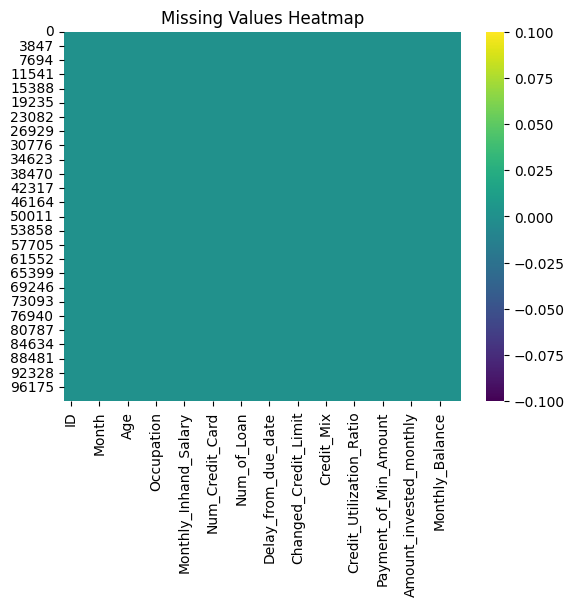

In [8]:
# Visualizing the missing values
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(df.isnull(), cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()


### What did you know about your dataset?

Answer Here

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
df.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [10]:
# Dataset Describe
df.describe()

,ID,Customer_ID,Month,Age,SSN,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,...,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,...,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,80631.500000,25982.666640,4.500000,33.316340,5.004617e+08,50505.123449,4197.270835,5.368820,5.533570,14.53208,...,21.08141,13.313120,10.470323,5.798250,1426.220376,32.285173,221.220460,107.699208,55.101315,392.697586
std,43301.486619,14340.543051,2.291299,10.764812,2.908267e+08,38299.422093,3186.432497,2.593314,2.067098,8.74133,...,14.80456,6.237166,6.609481,3.867826,1155.129026,5.116875,99.680716,132.267056,39.006932,201.652719
min,5634.000000,1006.000000,1.000000,14.000000,8.134900e+04,7005.930000,303.645417,0.000000,0.000000,1.00000,...,0.00000,0.000000,0.500000,0.000000,0.230000,20.000000,1.000000,0.000000,0.000000,0.007760
25%,43132.750000,13664.500000,2.750000,24.000000,2.451686e+08,19342.972500,1626.594167,3.000000,4.000000,7.00000,...,10.00000,9.000000,5.380000,3.000000,566.072500,28.052567,144.000000,29.268886,27.959111,267.615983
50%,80631.500000,25777.000000,4.500000,33.000000,5.006886e+08,36999.705000,3095.905000,5.000000,5.000000,13.00000,...,18.00000,14.000000,9.400000,5.000000,1166.155000,32.305784,219.000000,66.462304,45.156550,333.865366
75%,118130.250000,38385.000000,6.250000,42.000000,7.560027e+08,71683.470000,5957.715000,7.000000,7.000000,20.00000,...,28.00000,18.000000,14.850000,8.000000,1945.962500,36.496663,302.000000,147.392573,71.295797,463.215683
max,155629.000000,50999.000000,8.000000,56.000000,9.999934e+08,179987.280000,15204.633333,11.000000,11.000000,34.00000,...,62.00000,25.000000,29.980000,17.000000,4998.070000,50.000000,404.000000,1779.103254,434.191089,1183.930696


### Variables Description

Answer Here

### Check Unique Values for each variable.

In [11]:
# no of Unique Values for each variable.
print(df.nunique())
print('-'*60)

#what are the actual  values present for every variable
for col in df.columns:
    print(f"Column: {col}")
    print(df[col].unique())
    print('-'*60)



ID                          100000
Customer_ID                  12500
Month                            8
Name                         10128
Age                             43
SSN                          12500
Occupation                      15
Annual_Income                12488
Monthly_Inhand_Salary        13241
Num_Bank_Accounts               12
Num_Credit_Card                 12
Interest_Rate                   34
Num_of_Loan                     10
Type_of_Loan                  6261
Delay_from_due_date             63
Num_of_Delayed_Payment          26
Changed_Credit_Limit          3452
Num_Credit_Inquiries            18
Credit_Mix                       3
Outstanding_Debt             12203
Credit_Utilization_Ratio    100000
Credit_History_Age             404
Payment_of_Min_Amount            3
Total_EMI_per_month          11890
Amount_invested_monthly      12261
Payment_Behaviour                6
Monthly_Balance              98494
Credit_Score                     3
dtype: int64
-------

## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Write your code to make your dataset analysis ready.
df =df.replace(['_','-','NM',''],np.nan)
df.info()

#lets transform types
# 2. List of columns that SHOULD be numbers
# Note: In this dataset, Age and Annual_Income also often have stray '_'
num_cols = [
    "Age", "Annual_Income", "Num_of_Loan", "Num_Bank_Accounts",
    "Num_Credit_Card", "Interest_Rate", "Num_of_Delayed_Payment",
    "Changed_Credit_Limit", "Outstanding_Debt", "Amount_invested_monthly",
    "Monthly_Balance"
]

for col in num_cols:
    # This strips the stray '_' from the strings and converts to float
    # 'errors=coerce' turns the weird text into NaN automatically
    df[col] = pd.to_numeric(df[col].astype(str).str.strip('_'), errors='coerce')

# 3. Now that they are numbers, we can round and cast to Int for the counts
int_like_cols = ["Num_of_Loan", "Num_Credit_Card", "Num_Bank_Accounts", "Num_of_Delayed_Payment"]
for col in int_like_cols:
    df[col] = df[col].round().astype("Int64")

# 4. Clean up the ratios
df["Credit_Utilization_Ratio"] = df["Credit_Utilization_Ratio"].round(2)
df["Total_EMI_per_month"] = df["Total_EMI_per_month"].round(2)




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  int64  
 1   Customer_ID               100000 non-null  int64  
 2   Month                     100000 non-null  int64  
 3   Name                      100000 non-null  object 
 4   Age                       100000 non-null  float64
 5   SSN                       100000 non-null  float64
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     100000 non-null  float64
 9   Num_Bank_Accounts         100000 non-null  float64
 10  Num_Credit_Card           100000 non-null  float64
 11  Interest_Rate             100000 non-null  float64
 12  Num_of_Loan               100000 non-null  float64
 13  Type_of_Loan              100000 non-null  ob

In [13]:
import re

# 1. Handle 'Payment_of_Min_Amount' first as we discussed
df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].fillna('Unknown')

# 2. Transform 'Credit_History_Age' into Total Months
def extract_months(text):
    if pd.isna(text):
        return np.nan
    # Find all numbers in the string (e.g., "22" and "1")
    numbers = re.findall(r'\d+', str(text))
    if len(numbers) == 2:
        return (int(numbers[0]) * 12) + int(numbers[1])
    elif len(numbers) == 1: # In case it only says "Years" or only "Months"
        return int(numbers[0]) * 12 if "Year" in str(text) else int(numbers[0])
    return np.nan

df['Credit_History_Age_Months'] = df['Credit_History_Age'].apply(extract_months)

# 3. Quick cleanup for 'Type_of_Loan'
# Since it's a messy string, let's just make it lowercase and strip spaces for now
df['Type_of_Loan'] = df['Type_of_Loan'].str.lower().str.strip()

# 4. Final Sanity Check
print(df.info())
print("\nSample of transformed Credit History Age:")
print(df[['Credit_History_Age', 'Credit_History_Age_Months']].head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 29 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         100000 non-null  int64  
 1   Customer_ID                100000 non-null  int64  
 2   Month                      100000 non-null  int64  
 3   Name                       100000 non-null  object 
 4   Age                        100000 non-null  float64
 5   SSN                        100000 non-null  float64
 6   Occupation                 100000 non-null  object 
 7   Annual_Income              100000 non-null  float64
 8   Monthly_Inhand_Salary      100000 non-null  float64
 9   Num_Bank_Accounts          100000 non-null  Int64  
 10  Num_Credit_Card            100000 non-null  Int64  
 11  Interest_Rate              100000 non-null  float64
 12  Num_of_Loan                100000 non-null  Int64  
 13  Type_of_Loan               100

In [14]:
#advanced feature engineering
df['Debt_to_Income_Ratio'] = (df['Outstanding_Debt'] / df['Annual_Income']) * 100

# 2. Estimated Monthly Expenses
df['Monthly_Expenses'] = df['Monthly_Inhand_Salary'] - df['Monthly_Balance']
# 3. Age Groups
def age_grouping(age):
    if age < 18: return 'Minor'
    elif age <= 30: return 'Young Adult'
    elif age <= 50: return 'Adult'
    else: return 'Senior'



df['Age_Group'] = df['Age'].apply(age_grouping)

# IMPORTANT: Don't forget to update your 'df_summary' after creating these!
# Consolidate all aggregations into one summary DataFrame creation
df_summary = df.groupby('Customer_ID').agg({
    'Age': 'mean',
    'Annual_Income': 'mean',
    'Monthly_Inhand_Salary': 'mean',
    'Num_Bank_Accounts': 'max',
    'Outstanding_Debt': 'mean',
    'Credit_Utilization_Ratio': 'mean',
    'Credit_History_Age_Months': 'max',
    'Credit_Score': 'last',
    'Occupation': 'first',
    'Debt_to_Income_Ratio': 'mean',
    'Monthly_Expenses': 'mean',
    'Age_Group': 'first',
    'Num_of_Delayed_Payment': 'max'
}).reset_index()

df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Credit_History_Age_Months,Debt_to_Income_Ratio,Monthly_Expenses,Age_Group
0,5634,3392,1,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3,...,No,49.57,21.46538,High_spent_Small_value_payments,312.494089,Good,3180,4.2376,1512.349245,Young Adult
1,5635,3392,2,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3,...,No,49.57,21.46538,Low_spent_Large_value_payments,284.629162,Good,3192,4.2376,1540.214171,Young Adult
2,5636,3392,3,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3,...,No,49.57,21.46538,Low_spent_Medium_value_payments,331.209863,Good,3204,4.2376,1493.633470,Young Adult
3,5637,3392,4,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3,...,No,49.57,21.46538,Low_spent_Small_value_payments,223.451310,Good,3216,4.2376,1601.392024,Young Adult
4,5638,3392,5,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3,...,No,49.57,21.46538,High_spent_Medium_value_payments,341.489231,Good,3228,4.2376,1483.354102,Young Adult


In [15]:
#fundamental analysis for our summary table
df_summary.head()
print('-'*30)
print(df_summary.info())
print('-'*30)
print(df_summary.duplicated().sum())
print('-'*30)



------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12500 entries, 0 to 12499
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Customer_ID                12500 non-null  int64  
 1   Age                        12500 non-null  float64
 2   Annual_Income              12500 non-null  float64
 3   Monthly_Inhand_Salary      12500 non-null  float64
 4   Num_Bank_Accounts          12500 non-null  Int64  
 5   Outstanding_Debt           12500 non-null  float64
 6   Credit_Utilization_Ratio   12500 non-null  float64
 7   Credit_History_Age_Months  12500 non-null  int64  
 8   Credit_Score               12500 non-null  object 
 9   Occupation                 12500 non-null  object 
 10  Debt_to_Income_Ratio       12500 non-null  float64
 11  Monthly_Expenses           12500 non-null  float64
 12  Age_Group                  12500 non-null  object 
 13  Num_of_Delayed_

### What all manipulations have you done and insights you found?

Answer Here.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

C:\Users\kaushik\AppData\Local\Temp\ipykernel_20620\2262720798.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'Credit_Score' ,  data = df_summary , palette=['blue','green','yellow'] )


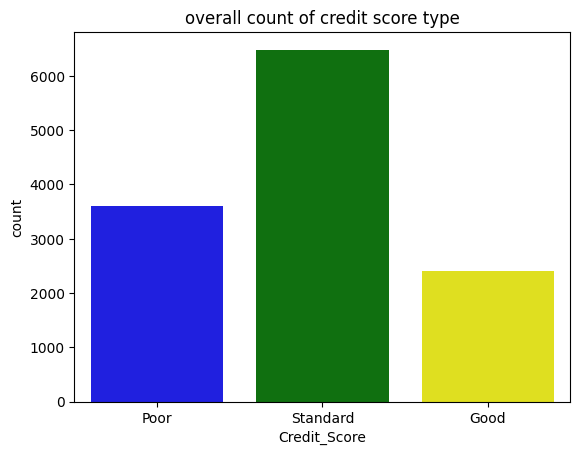

In [16]:
# Chart - 1 visualization code
sns.countplot(x = 'Credit_Score' ,  data = df_summary , palette=['blue','green','yellow'] )
plt.title('overall count of credit score type')
plt.show()

##### 1. Why did you pick the specific chart?

A count plot is the most effective tool for categorical data because it allows us to visually calculate frequencies immediately without the distraction of percentages or complex calculations.

##### 2. What is/are the insight(s) found from the chart?

The "Standard" Dominance: The "Standard" credit score category is by far the largest segment in our portfolio, containing over 6,000 customers in this snapshot (nearly double the size of the "Poor" or "Good" buckets individually).

The Underperforming Portfolio: "Poor" risk profiles outnumber our top-tier "Good" customers.

The Normal-ish Curve: The overall distribution mimics a bell curve centered tightly on average risk, indicating that our data is highly centralized rather than polarized into extremes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

3. Business Impact
📈 Positive Growth (Opportunities)
Target the Middle: Since most customers are "Standard," we can launch targeted Credit-Builder Products to upgrade them to "Good," unlocking higher-value, safer lending loops.

📉 Negative Growth (Risks to Mitigate)
High Default Exposure: Having more "Poor" than "Good" customers is a major threat. A sudden economic dip could cause massive loan write-offs. Underwriting needs to tighten immediately to restrict new high-risk sign-ups.

#### Chart - 2

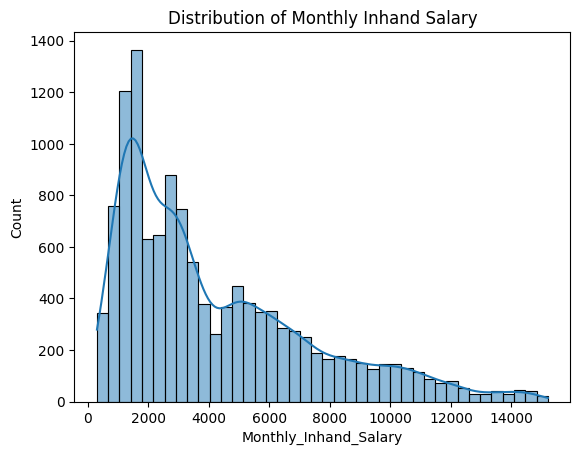

In [17]:
# Chart - 2 visualization code
sns.histplot(data =  df_summary , x = 'Monthly_Inhand_Salary', kde =True )
plt.title('Distribution of Monthly Inhand Salary')
plt.show()

##### 1. Why did you pick the specific chart?

A histogram with a KDE curve shows the shape, central tendency, and spread of our customers' disposable monthly income. It helps the bank understand the actual cash liquidity available to its users each month

##### 2. What is/are the insight(s) found from the chart?

Right-Skewed Distribution: The data is heavily skewed to the right. The vast majority of our customer base clusters tightly at the lower end, specifically between $\$1,000$ and $\$4,000$ per month.The Long Tail: There is a long, thin tail extending toward higher salaries up to $\$15,000$, showing that high-income earners make up a very small minority of our portfolio.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 3

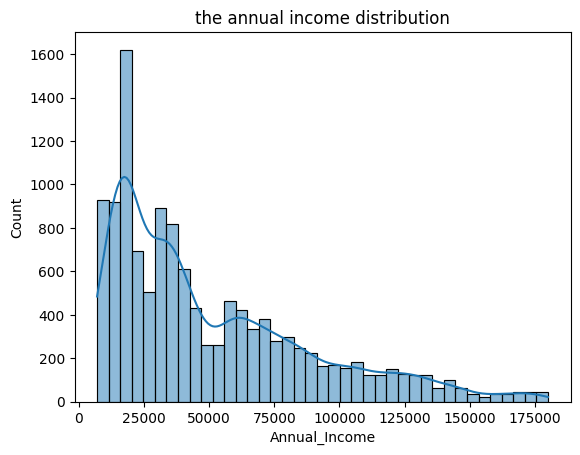

In [18]:
# Chart - 3 visualization code
sns.histplot( x = 'Annual_Income' , data = df_summary, kde = True)
plt.title('the annual income distribution')
plt.show()

##### 1. Why did you pick the specific chart?

A histogram of annual income maps out the macroeconomic capacity of our customer base. While monthly salary shows immediate cash flow, annual income shows sustained earning power, which banks use to set maximum credit limits.

##### 2. What is/are the insight(s) found from the chart?

he $15,000 - $20,000$ Spike: There is a massive, highly concentrated peak right around $15,000$ to $20,000$. This represents our single largest customer demographic.Multimodal Ripples: Notice the smaller secondary waves or "bumps" around $35,000$ and $60,000$? This indicates distinct economic classes or professional tiers within our bank's user base.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

📈 Positive Growth (Opportunities)Tiered Product Structuring: The distinct "bumps" in the chart allow the marketing team to segment customers perfectly into income brackets:Entry Tier: Under $25,000$ (Micro-loans/Basic Cards)Mid Tier: $25,000 - $75,000$ (Standard Rewards Cards/Auto Loans)Premium Tier: Above $75,000$ (Wealth Management/Premium Cards)📉 Negative Growth (Risks to Mitigate)Low Ticket Pre-Approvals: Because the massive peak sits below $25,000$, our overall lending capacity per user is restricted. If the bank aggressively pushes high-limit credit lines to this dominant lower bracket to chase growth, it will face a severe spike in bad loans. Keeping credit limits conservative for this tier is critical for survival.

#### Chart - 4

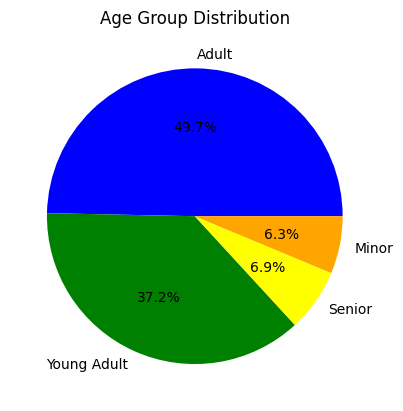

In [19]:
# Chart - 4 visualization code
plt.pie(df_summary['Age_Group'].value_counts(), labels=df_summary['Age_Group'].value_counts().index, autopct='%1.1f%%', colors=['blue', 'green', 'yellow', 'orange'])
plt.title('Age Group Distribution')
plt.show()

##### 1. Why did you pick the specific chart?

A pie chart is selected here to show the parts-of-a-whole relationship for our engineered Age_Group feature. It allows executives to see at a glance which generation dominates our user base.

##### 2. What is/are the insight(s) found from the chart?

The Core Demographic: "Adults" 49.7  and "Young Adults" 37.2 form the overwhelming majority, combining to make up roughly 87 of all customers.The Minorities: "Seniors" 6.9 and "Minors" 6.3 represent a tiny fraction of the total bank profile.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

📈 Positive Growth (Opportunities)Digital & Prime Product Focus: Because nearly $87\%$ of the user base is under 50, the bank should heavily prioritize modern mobile banking features, instant digital loan pre-approvals, and investment options (like mutual funds or stocks) that appeal directly to working professionals and tech-savvy young adults.📉 Negative Growth (Risks to Mitigate)Legacy Product Stagnation: Spending heavy capital on traditional brick-and-mortar branch expansions or legacy phone-banking services targeting "Seniors" will yield a negative return on investment (ROI) due to the low customer volume.Compliance Check: The presence of $6.3\%$ "Minors" flags a compliance requirement. The bank must ensure strict regulatory safeguards are in place for these accounts (e.g., parental oversight locks) to avoid legal penalties.

#### Chart - 5

C:\Users\kaushik\AppData\Local\Temp\ipykernel_20620\3832505854.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_summary, x='Credit_Score', y='Debt_to_Income_Ratio',


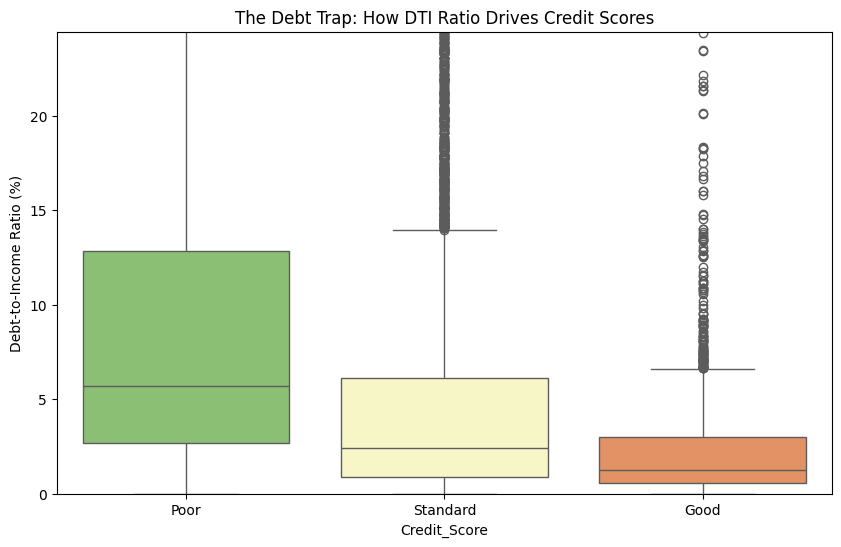

In [20]:
# Chart - 5 visualization code
plt.figure(figsize=(10, 6))
# Order matters! It shows the 'trend' from worst to best
sns.boxplot(data=df_summary, x='Credit_Score', y='Debt_to_Income_Ratio',
            order=['Poor', 'Standard', 'Good'], palette='RdYlGn_r')

# If there are extreme outliers, we can zoom in to see the boxes better
plt.ylim(0, df_summary['Debt_to_Income_Ratio'].quantile(0.95))

plt.title('The Debt Trap: How DTI Ratio Drives Credit Scores')
plt.ylabel('Debt-to-Income Ratio (%)')
plt.show()

##### 1. Why did you pick the specific chart?

A box plot is the gold standard for Bivariate Analysis when comparing a categorical variable (Credit_Score) with a continuous numerical variable (Debt_to_Income_Ratio). It allows us to compare the median, quartiles, and outlier density across risk tiers simultaneously.

##### 2. What is/are the insight(s) found from the chart?

Clear Risk Progression: The median DTI drops sharply as credit health improves. "Poor" profiles have a median DTI around $5.7\%$, "Standard" sits around $2.5\%$, and "Good" drops to just over $1.0\%$.The Overlap Reality: The "Standard" box heavily overlaps with the lower half of the "Poor" box. This reveals that keeping a low DTI does not automatically guarantee safety—other negative behaviors are dragging down many low-DTI individuals.Mass Outlier Density: The "Standard" and "Good" segments show a massive vertical stack of extreme outliers extending far above their upper whiskers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

 Positive Growth (Opportunities)Underwriting Automation: The tight, low box for the "Good" group means the bank can safely automate loan pre-approvals for any applicant with a DTI under $3.0\%$, provided their other baseline habits match up. This drops manual processing costs drastically.📉 Negative Growth (Risks to Mitigate)The "Hidden Risk" Outliers: The extreme outliers in the "Good" and "Standard" categories represent dangerous systemic risks. These are users who currently hold a positive rating but carry massive, unsustainable debt loads relative to their income. The risk team must flag these accounts for proactive credit limit freezes before they unexpectedly collapse into default.

#### Chart - 6

C:\Users\kaushik\AppData\Local\Temp\ipykernel_20620\2246826605.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot( x = 'Credit_Score',


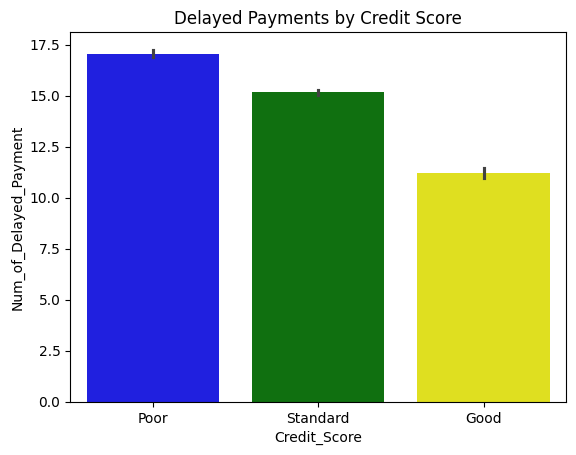

In [21]:
# Chart - 6 visualization code
sns.barplot( x = 'Credit_Score',
             y = 'Num_of_Delayed_Payment' ,
             data = df_summary ,
             palette=['blue','green','yellow'] ,
             )
plt.title('Delayed Payments by Credit Score')
plt.show()


##### 1. Why did you pick the specific chart?

A bar plot displaying averages with confidence interval whiskers allows us to evaluate behavioral trends across customer segments. It specifically answers how strongly repayment punctuality influences final risk profiling

##### 2. What is/are the insight(s) found from the chart?

The Punctuality Step-Down: There is a clear, stepwise reduction in late payments across groups. "Poor" accounts average roughly 17 delayed payments, "Standard" drops to 15, and "Good" cuts down significantly to around 11.

Extremely Tight Confidence Intervals: The tiny black error bars at the top of each bar indicate highly consistent behavior within each category. The data isn't volatile; these averages represent stable behavioral realities for each group.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Growth (Opportunities)
Gamified Behavioral Interventions: Because the gap between a "Standard" customer and a "Good" customer is roughly 4 late payments over the tracking period, the bank can launch Punctuality Campaigns. Offering automated notifications, calendar integrations, or minor cash-back incentives to reduce delayed payments will systematically migrate standard users into lower-risk categories.

📉 Negative Growth (Risks to Mitigate)
The "Good but Late" Threat: Alarmingly, even the highest-tier "Good" customers average over 11 delayed payments. This indicates that our portfolio has a high tolerance for chronic lateness. The bank is exposing itself to minor cash flow bottlenecks because even its best tier is frequently behind schedule. The collections department needs to optimize its early-stage reminder sequences immediately.

#### Chart - 7

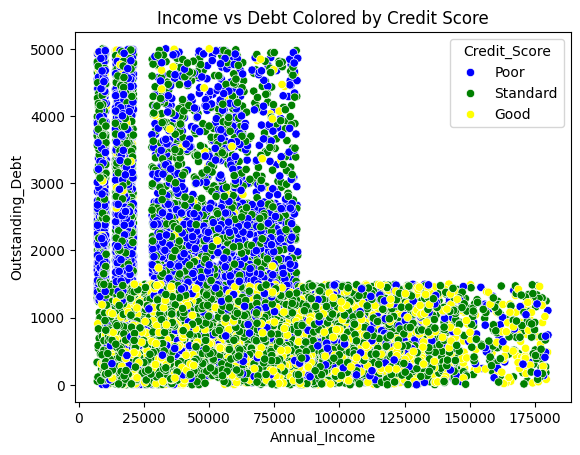

In [22]:
# Chart - 7 visualization code
# Lets run a scatterplot !!

sns.scatterplot( x = 'Annual_Income' , y = 'Outstanding_Debt' , data = df_summary , hue = 'Credit_Score' , palette=['blue','green','yellow'] )
plt.title('Income vs Debt Colored by Credit Score')
plt.show()


##### 1. Why did you pick the specific chart?

A multivariate scatter plot maps the interaction between two continuous variables (Annual_Income and Outstanding_Debt) while using a categorical hue (Credit_Score) to instantly locate visible decision boundaries, risk thresholds, and clusters.

##### 2. What is/are the insight(s) found from the chart?

The $\$1,500$ Debt Ceiling: There is a sharp, absolute structural barrier at $\$1,500$ of outstanding debt. Below $\$1,500$, customers across all income levels (up to $\$180,000$) coexist with highly mixed credit scores.The "High Debt" Lockout: Above $\$1,500$ of debt, the data changes dramatically. First, no data exists for anyone earning more than roughly $\$85,000$. Second, the visual space turns heavily blue and green, meaning high debt is strictly populated by "Poor" and "Standard" scores.The Outlier Gap: Notice the vertical blank white strip between $\$22,000$ and $\$28,000$ for debts over $\$1,500$? This points to an artificial data anomaly or a highly specific, missing bracket in the bank's historical loan approvals.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Hardcoded Risk Rule Implementation: The visualization provides clear mathematical proof for credit policy automation. The risk team can safely implement an automated hard rule: “If an applicant's outstanding debt is under $\$1,500$, income is an open variable; if debt exceeds $\$1,500$, cap the maximum allowable debt line strictly proportional to income below $\$85,000$.” #### 📉 Negative Growth (Risks to Mitigate)Low-Income Debt Concentration: The dense blue tower on the far left reveals a high concentration of low-income individuals (under $\$25,000$) carrying maxed-out debts up to $\$5,000$. This specific cluster represents the highest risk of systemic defaults. The bank must aggressively pause credit extensions to this group, as their debt-to-income balance is highly unsustainable.

#### Chart - 8

C:\Users\kaushik\AppData\Local\Temp\ipykernel_20620\1891341929.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_summary, x='Credit_Score', y='Num_Bank_Accounts',


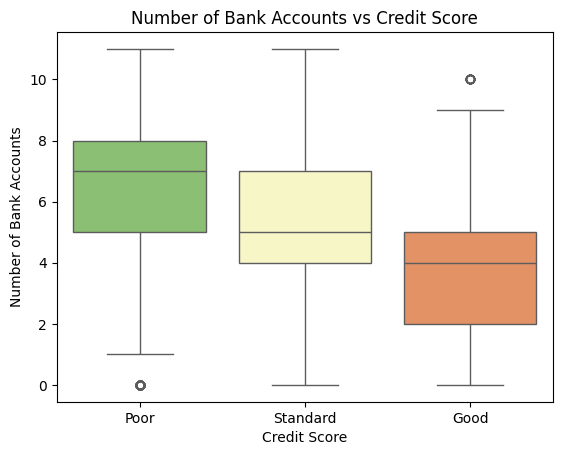

In [23]:
# Chart - 8 visualization code
#num of bank _accounts vs thier credit score
sns.boxplot(data=df_summary, x='Credit_Score', y='Num_Bank_Accounts',
            order=['Poor', 'Standard', 'Good'], palette='RdYlGn_r')
plt.title('Number of Bank Accounts vs Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Number of Bank Accounts')
plt.show()



##### 1. Why did you pick the specific chart?

A box plot is chosen here to evaluate the distribution and spread of a discrete numerical variable (Number of Bank Accounts) across different categorical risk tiers (Credit Score). It helps test the financial hypothesis: Does owning too many financial accounts correlate with higher risk?

##### 2. What is/are the insight(s) found from the chart?

The Account Staircase: There is a distinct, downward step-pattern in account ownership as credit health improves. "Poor" credit profiles have a median of 7 bank accounts, "Standard" drops to 5, and "Good" cuts down cleanly to 4.

Tight Range for Top Tier: The "Good" category box is compressed between 2 and 5 accounts. This indicates that financially stable individuals prefer to centralize and simplify their banking footprint.

The "Zero Account" Outliers: Notice the outlier dots at 0 for the "Poor" category. This catches a data issue or individuals operating entirely without open bank accounts, which naturally penalizes credit profiles.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Growth (Opportunities)
Cross-Selling Boundaries: The data shows our best customers ("Good") rarely maintain more than 4-5 accounts. Instead of spamming our top-tier users to open new niche savings or secondary checking accounts, our sales team should focus on cross-selling high-margin wealth management or premium investment products that keep their capital concentrated with us.

📉 Negative Growth (Risks to Mitigate)
The "Account Hoarder" Red Flag: Applicants holding 7 or more active bank accounts are highly correlated with "Poor" credit. In banking, scattered accounts are a primary indicator of "credit shuffling" (moving debt around to hide a lack of liquidity). The risk team should add an automated penalty to our internal scoring model for anyone applying with more than 6 active accounts to protect against onboarding high-risk borrowers.

#### Chart - 9

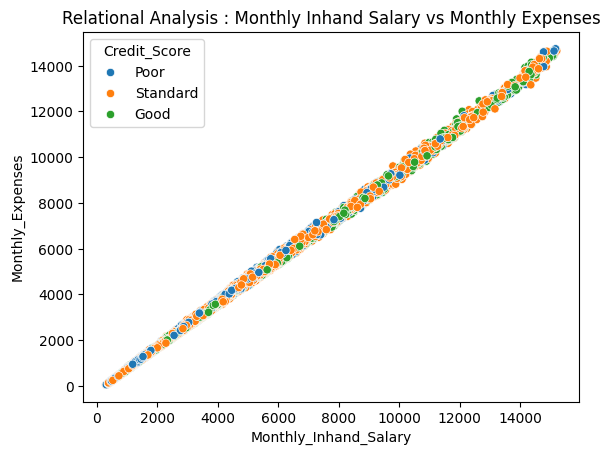

In [24]:
# Chart - 9 visualization code
sns.scatterplot(x= 'Monthly_Inhand_Salary' ,
                y = 'Monthly_Expenses',
                hue = 'Credit_Score' ,
                data = df_summary,
                )
plt.title('Relational Analysis : Monthly Inhand Salary vs Monthly Expenses')
plt.show()


##### 1. Why did you pick the specific chart?

A multivariate scatter plot maps the relationship between cash inflows (Monthly_Inhand_Salary) and outflows (Monthly_Expenses) across risk segments (Credit_Score). It reveals baseline savings capacity and helps catch major data anomalies.

##### 2. What is/are the insight(s) found from the chart?

The Perfect Linear Lockstep: There is a near-perfect, deterministic linear correlation between salary and expenses. If a customer's income scales up, their recorded expenses scale up at an almost identical, rigid rate.The $\$0$ Savings Trap: Because the line is incredibly tight and diagonal, it indicates that all customers—regardless of whether they make $\$2,000$ or $\$14,000$ a month—are spending almost their entire paycheck.Zero Credit Score Discrimination: Look at the colors. Blue, orange, and green dots are completely mixed together from bottom to top. This proves that, strangely, a customer's basic spending-to-salary ratio has zero impact on their final credit score calculation in this dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

📈 Positive Growth (Opportunities)
Algorithmic Lifestyle-Creep Modeling: Since spending tracks income perfectly, our product teams can launch automated, pre-approved Credit Limit Increase (CLI) Triggers. When a user's salary bump is detected via direct deposit, the system can instantly calculate their new predictable spending tier and proactively offer higher credit card limits to capture their increased transaction volume.

📉 Negative Growth (Risks to Mitigate)
Data Quality Red Flag:. Real human spending is messy and volatile. This "perfect line" strongly suggests an artificial synthetic data generation formula or a heavily constrained data pipeline. The risk team must verify the collection source before using this specific expense variable in real-world machine learning models, as it lacks organic predictive behavior.

#### Chart - 10

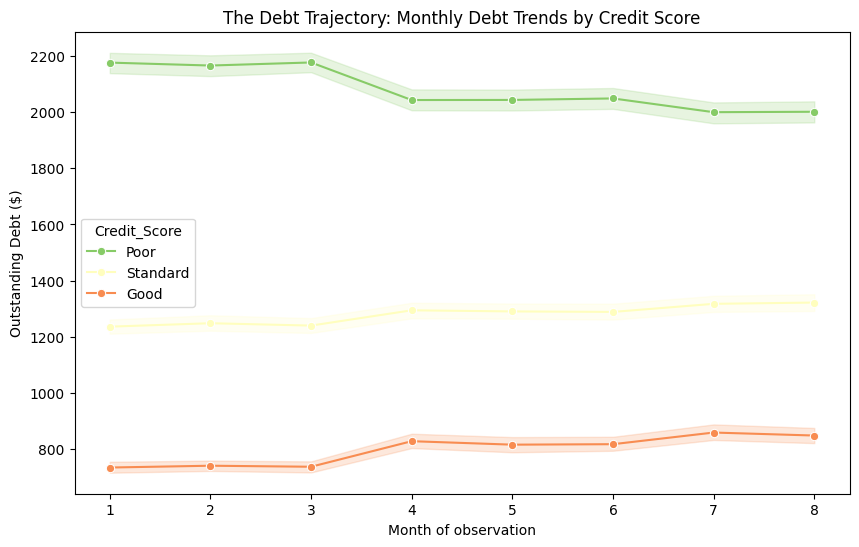

In [25]:

# Chart - 10 visualization code

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# Using the main df to see the monthly progression
sns.lineplot(data=df, x='Month', y='Outstanding_Debt', hue='Credit_Score',
             hue_order=['Poor', 'Standard', 'Good'], palette='RdYlGn_r', marker='o')

plt.title('The Debt Trajectory: Monthly Debt Trends by Credit Score')
plt.xlabel('Month of observation')
plt.ylabel('Outstanding Debt ($)')
plt.show()

##### 1. Why did you pick the specific chart?

A line plot with shaded confidence bands tracks changes across time (Month of observation). Using the full df dataset exposes the trajectory of financial health rather than a static snapshot. It answers if customers improve their debt positions over time or remain stuck.

##### 2. What is/are the insight(s) found from the chart?

The Month 3 to 4 Inflection Point: Look closely at Month 4. Across all three risk tiers simultaneously, the trajectories change. The "Poor" group suddenly drops by roughly $\$150$ in debt, while the "Standard" and "Good" groups experience a noticeable increase in debt. This synchronized shift indicates an external macroeconomic event or bank-wide balance adjustments occurring in that specific month.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The "Month 4" Portfolio Recovery Insight: The synchronized shift suggests a major seasonal event—such as tax refund distribution or corporate bonus cycles—where high-risk users aggressively pay down balances. The collections and marketing teams can time their major automated loan settlement or recovery campaigns precisely in Month 3 to capitalize on this natural inflow of customer liquidity.

📉 Negative Growth (Risks to Mitigate)
Chronic Debt Stagnation: Notice how flat the lines remain from Month 4 onwards. Customers are not actively deleveraging. "Poor" accounts remain heavily burdened, while "Standard" and "Good" users show minor upward debt drift by Month 8. This flat trend means users are carrying revolving balances monthly rather than clearing them, exposing the bank to heightened, long-term default risk if economic conditions tighten.

#### Chart - 11 - Correlation Heatmap

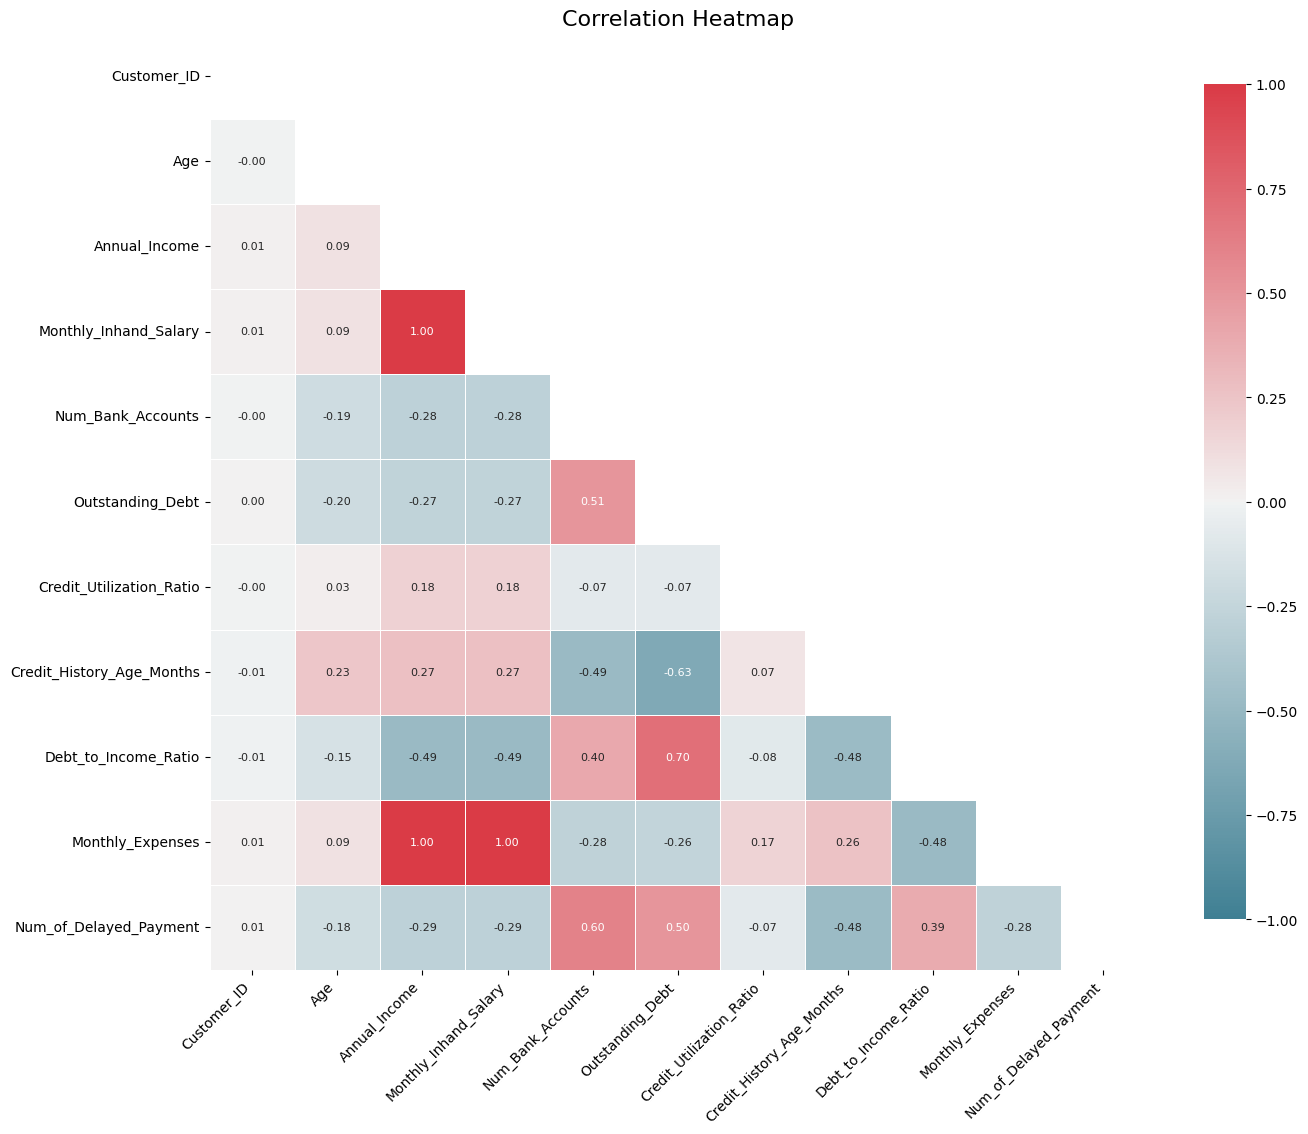

In [26]:
# Correlation Heatmap visualization code
import numpy as np

numeric_columns = df_summary.select_dtypes(include=['number']).columns
correlation_matrix = df[numeric_columns].corr()

# Reduce to top features when there are many numeric columns
if correlation_matrix.shape[0] > 20:
    top_n = 20
    strongest = correlation_matrix.abs().sum().sort_values(ascending=False).head(top_n).index
    correlation_matrix = correlation_matrix.loc[strongest, strongest]

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
cmap = sns.diverging_palette(220, 10, as_cmap=True)

sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cmap=cmap,
    vmin=-1,
    vmax=1,
    square=True,
    cbar_kws={'shrink': 0.8},
    annot_kws={'size': 8}
)

plt.title('Correlation Heatmap', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



##### 1. Why did you pick the specific chart?

A triangular correlation heatmap visually condenses the Pearson correlation coefficients between all numerical features in our dataset. This is a critical step before building machine learning models to detect multicollinearity (features that repeat the same information) and identify strong statistical relationships.

##### 2. What is/are the insight(s) found from the chart?

Key InsightsThe Multicollinearity Red Flags (Perfect 1.00s): There is a perfect positive correlation ($1.00$) between Annual_Income and Monthly_Inhand_Salary, which is expected. However, as noted in Chart 9, Monthly_Expenses also correlates at a perfect $1.00$ with both income metrics.The Strong Risk Drivers: Outstanding_Debt shares a very strong positive correlation with Debt_to_Income_Ratio ($0.70$) and a solid correlation with Num_of_Delayed_Payment ($0.50$). Additionally, Num_Bank_Accounts and Num_of_Delayed_Payment have a strong positive correlation ($0.60$).The Punctuality Cushion: Credit_History_Age_Months has a strong negative correlation with Outstanding_Debt ($-0.63$), Num_of_Delayed_Payment ($-0.48$), and Debt_to_Income_Ratio ($-0.48$). This proves that customers with longer financial footprints manage their debts much more cleanly.

#### Chart - 12 - Pair Plot

c:\Users\kaushik\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\seaborn\axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)
c:\Users\kaushik\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\seaborn\axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)
c:\Users\kaushik\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\seaborn\axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)
c:\Users\kaushik\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\seaborn\axisgrid.py:1513: FutureWarning: 

`shade` is now 

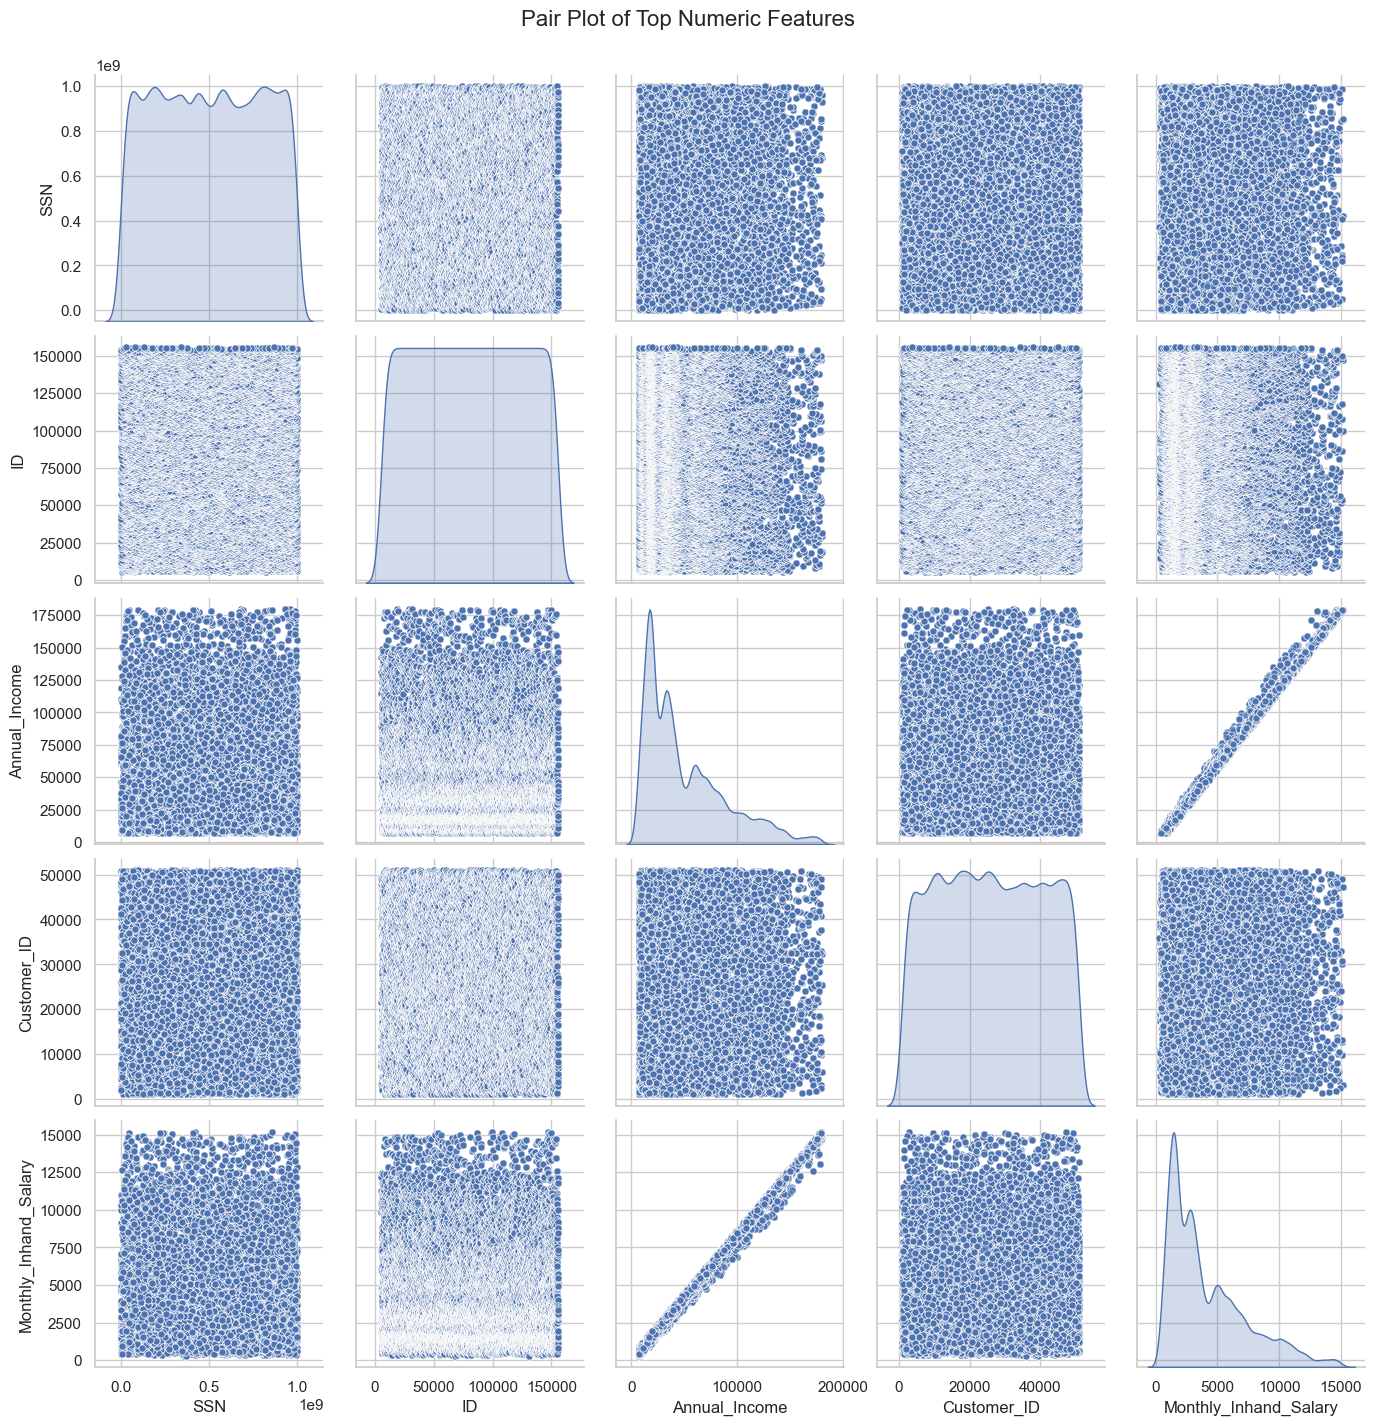

In [27]:
# Pair Plot visualization code
numeric_columns = df.select_dtypes(include=['number']).columns.tolist()

if len(numeric_columns) > 5:
    selected = df[numeric_columns].var().sort_values(ascending=False).head(5).index.tolist()
else:
    selected = numeric_columns

hue_col = None
for candidate in ['target', 'class', 'label', 'species']:
    if candidate in df.columns:
        if df[candidate].dtype == 'object' or df[candidate].nunique() <= 10:
            hue_col = candidate
            break

plot_data = df[selected + ([hue_col] if hue_col else [])].dropna()

sns.set_theme(style='whitegrid')
pairplot = sns.pairplot(
    plot_data,
    vars=selected,
    hue=hue_col,
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 25},
    diag_kws={'shade': True},
    height=2.8
)

pairplot.fig.suptitle('Pair Plot of Top Numeric Features', y=1.02, fontsize=16)
plt.show()


##### 1. Why did you pick the specific chart?

A pair plot provides an all-in-one matrix of scatter plots for every pairwise combination of numeric features, along with their individual distributions on the diagonal. It is used to instantly identify linear relationships, clusters, and data uniformities across multiple dimensions simultaneously.

##### 2. What is/are the insight(s) found from the chart?

Key Insights
The Noise Identifiers (Perfect Uniform Blocks): Features like SSN, ID, and Customer_ID form perfectly solid, uniform square blocks when plotted against other variables. Their individual diagonal distributions are flat, box-like plateaus. This visually proves that these variables are completely random, uniformly distributed identifiers containing zero predictive value.

The Income-Salary Duplication: The intersection between Annual_Income and Monthly_Inhand_Salary forms a perfectly tight, diagonal straight line. This visual duplication confirms that they share a deterministic relationship, completely mirroring the insights from our correlation heat

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

1. Risk-Tiered Underwriting Automation
Action: Hardcode automated credit limits and pre-approval loops using clear thresholds found in the data (e.g., locking fast-tracked approvals to applicants with a DTI under 3% and fewer than 5 active bank accounts).

Impact: Lowers manual operational costs and drastically accelerates customer onboarding for low-risk tiers.

2. Launch Targeted "Credit-Builder" Products
Action: Create customized low-barrier financial products and proactive gamified payment reminders targeted directly at the massive "Standard" risk category.

Impact: Intentionally migrates borderline mid-tier users into safe, high-value, long-term "Good" tier borrowers, organically increasing the bank's safe revenue.

3. Implement Multi-Account Penalty Safeguards
Action: Update the internal risk scoring engine to automatically trigger friction, manual reviews, or credit freezes when an applicant holds more than 6 active bank accounts or displays extreme outlier debt positions.

Impact: Proactively protects the portfolio against "credit shuffling" and sudden spikes in non-performing assets (NPAs) before an economic downturn hits.

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***

In [28]:
#machine learning begins here 
df_summary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12500 entries, 0 to 12499
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Customer_ID                12500 non-null  int64  
 1   Age                        12500 non-null  float64
 2   Annual_Income              12500 non-null  float64
 3   Monthly_Inhand_Salary      12500 non-null  float64
 4   Num_Bank_Accounts          12500 non-null  Int64  
 5   Outstanding_Debt           12500 non-null  float64
 6   Credit_Utilization_Ratio   12500 non-null  float64
 7   Credit_History_Age_Months  12500 non-null  int64  
 8   Credit_Score               12500 non-null  object 
 9   Occupation                 12500 non-null  object 
 10  Debt_to_Income_Ratio       12500 non-null  float64
 11  Monthly_Expenses           12500 non-null  float64
 12  Age_Group                  12500 non-null  object 
 13  Num_of_Delayed_Payment     12500 non-null  Int

In [29]:
df_summary["Net_Monthly_Savings"] = (
    df_summary["Monthly_Inhand_Salary"] - df_summary["Monthly_Expenses"]
)

# 2. Savings-to-Income Ratio
# Measures how much of their paycheck is left over after expenses
df_summary["Savings_To_Income_Ratio"] = df_summary["Net_Monthly_Savings"] / (
    df_summary["Monthly_Inhand_Salary"] + 1e-5
)

# 3. Delay per Bank Account
# Standardizes delayed payments against account exposure
df_summary["Delay_Per_Account"] = df_summary["Num_of_Delayed_Payment"] / (
    df_summary["Num_Bank_Accounts"] + 1
)

# 4. Debt Burden Relative to Credit History Length
# High debt with short credit history = higher default probability
df_summary["Debt_To_History_Age"] = df_summary["Outstanding_Debt"] / (
    df_summary["Credit_History_Age_Months"] + 1
)

In [30]:
#distribution of target variable
df_summary['Credit_Score'].value_counts() 

Credit_Score
Standard    6485
Poor        3602
Good        2413
Name: count, dtype: int64

In [31]:
df_summary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12500 entries, 0 to 12499
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Customer_ID                12500 non-null  int64  
 1   Age                        12500 non-null  float64
 2   Annual_Income              12500 non-null  float64
 3   Monthly_Inhand_Salary      12500 non-null  float64
 4   Num_Bank_Accounts          12500 non-null  Int64  
 5   Outstanding_Debt           12500 non-null  float64
 6   Credit_Utilization_Ratio   12500 non-null  float64
 7   Credit_History_Age_Months  12500 non-null  int64  
 8   Credit_Score               12500 non-null  object 
 9   Occupation                 12500 non-null  object 
 10  Debt_to_Income_Ratio       12500 non-null  float64
 11  Monthly_Expenses           12500 non-null  float64
 12  Age_Group                  12500 non-null  object 
 13  Num_of_Delayed_Payment     12500 non-null  Int

In [44]:
import os 

os.getcwd()

AttributeError: module 'os' has no attribute 'get_cwd'

In [32]:
import joblib
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, RobustScaler

In [33]:
X = df_summary.drop(
    columns=[
        "Credit_Score",
        "ID",
        "Customer_ID",
        "SSN",
        "Monthly_Inhand_Salary",
        "Monthly_Expenses",
    ],
    errors="ignore",
)

y = df_summary['Credit_Score']

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [35]:
print('Shape of our training set :',X_train.shape)
print('Shape of our testing set :', X_test.shape)

Shape of our training set : (10000, 14)
Shape of our testing set : (2500, 14)


In [36]:
#encoding of target variable 
le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

#encoding our independent variable 
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns 

Rc = RobustScaler()

#we dont need to encode our numerical variable since it is already in mumerica format
X_train_num = Rc.fit_transform(X_train[num_cols])
X_test_num = Rc.transform(X_test[num_cols])

#now we are encoding our categorical variable using one hot encoding
#Categorical columns do not need numerical scaling because One-Hot Encoding already places them on a 0-to-1 scale!
# 3. One-Hot Encode Categorical Features
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_train_cat = ohe.fit_transform(X_train[cat_cols])
X_test_cat = ohe.transform(X_test[cat_cols])

import pandas as pd

# 1. Convert numerical array back to DataFrame with original column names
X_train_num_df = pd.DataFrame(
    X_train_num, columns=num_cols, index=X_train.index
)
X_test_num_df = pd.DataFrame(X_test_num, columns=num_cols, index=X_test.index)

# 2. Get new One-Hot Encoded column names and create DataFrame
ohe_feature_names = ohe.get_feature_names_out(cat_cols)

X_train_cat_df = pd.DataFrame(
    X_train_cat, columns=ohe_feature_names, index=X_train.index
)
X_test_cat_df = pd.DataFrame(
    X_test_cat, columns=ohe_feature_names, index=X_test.index
)

# 3. Concatenate side-by-side (axis=1)
X_train_processed = pd.concat([X_train_num_df, X_train_cat_df], axis=1)
X_test_processed = pd.concat([X_test_num_df, X_test_cat_df], axis=1)

# Now you can inspect column names easily!
print(X_train_processed.head())

            Age  Annual_Income  Num_Bank_Accounts  Outstanding_Debt  \
8659   0.101449       0.531725              -0.25          0.056198   
4551  -0.333333       0.519986              -0.50         -0.141118   
11437  0.123188      -0.354996               0.75          0.837353   
4486   0.239130      -0.375304               0.25          1.010687   
5217  -0.637681       2.484923              -1.00         -0.306031   

       Credit_Utilization_Ratio  Credit_History_Age_Months  \
8659                   0.586227                   0.935897   
4551                  -0.532954                  -0.673077   
11437                  0.812521                  -0.365385   
4486                   0.936824                  -0.589744   
5217                   1.627092                   0.724359   

       Debt_to_Income_Ratio  Num_of_Delayed_Payment  Net_Monthly_Savings  \
8659              -0.153439               -0.444444             0.557750   
4551              -0.219886               -0.555

In [37]:
from sklearn.ensemble import RandomForestClassifier 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix,f1_score
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier 

In [38]:
lr = LogisticRegression(max_iter = 1000 , random_state = 42)
lr.fit(X_train_processed , y_train_encoded)
y_pred_lr = lr.predict(X_test_processed) 

print(classification_report(y_test_encoded, y_pred_lr))
print('-'*60)
print(confusion_matrix(y_test_encoded , y_pred_lr))
print('-'*60)
print(f"F1 Score: {f1_score(y_test_encoded, y_pred_lr, average='weighted'):.4f}")

              precision    recall  f1-score   support

           0       0.48      0.17      0.25       483
           1       0.53      0.30      0.38       720
           2       0.55      0.81      0.65      1297

    accuracy                           0.54      2500
   macro avg       0.52      0.43      0.43      2500
weighted avg       0.53      0.54      0.50      2500

------------------------------------------------------------
[[  81   14  388]
 [  23  213  484]
 [  65  177 1055]]
------------------------------------------------------------
F1 Score: 0.4967


In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Initialize Random Forest
# Using class_weight='balanced' ensures rare credit tiers are given proper weight
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42, 
    class_weight="balanced",
    n_jobs=-1
)

# 2. Fit using X_train_processed and y_train_encoded
rf.fit(X_train_processed, y_train_encoded)

# 3. Predict on X_test_processed
y_pred_rf = rf.predict(X_test_processed)

# 4. Evaluate Performance
print("=== RANDOM FOREST PERFORMANCE ===")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_encoded, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test_encoded, y_pred_rf))
print('-'*60)
print(f"F1 Score: {f1_score(y_test_encoded, y_pred_rf, average='weighted'):.4f}")

=== RANDOM FOREST PERFORMANCE ===

Confusion Matrix:
[[249  25 209]
 [106 463 151]
 [308 304 685]]

Classification Report:
              precision    recall  f1-score   support

           0       0.38      0.52      0.43       483
           1       0.58      0.64      0.61       720
           2       0.66      0.53      0.58      1297

    accuracy                           0.56      2500
   macro avg       0.54      0.56      0.54      2500
weighted avg       0.58      0.56      0.56      2500

------------------------------------------------------------
F1 Score: 0.5638


In [40]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=10,
    objective="multi:softprob",  # Outputs class probabilities for multi-class targets
    num_class=3,  # 3 target classes: 0, 1, 2
    random_state=42,
    n_jobs=-1,
)

# =========================================================
# STEP 2: FIT MODEL ON PROCESSED TRAINING DATA
# =========================================================
print("Training XGBoost Classifier...")
xgb_model.fit(X_train_processed, y_train_encoded)

# =========================================================
# STEP 3: PREDICT & EVALUATE ON TEST DATA
# =========================================================
y_pred_xgb = xgb_model.predict(X_test_processed)

print("\n=== XGBOOST CLASSIFIER PERFORMANCE ===")
print("\n--- CONFUSION MATRIX ---")
print(confusion_matrix(y_test_encoded, y_pred_xgb))

print("\n--- CLASSIFICATION REPORT ---")
print(
    classification_report(
        y_test_encoded, y_pred_xgb, target_names=le.classes_
    )
)

Training XGBoost Classifier...

=== XGBOOST CLASSIFIER PERFORMANCE ===

--- CONFUSION MATRIX ---
[[126  19 338]
 [ 49 344 327]
 [139 225 933]]

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

        Good       0.40      0.26      0.32       483
        Poor       0.59      0.48      0.53       720
    Standard       0.58      0.72      0.64      1297

    accuracy                           0.56      2500
   macro avg       0.52      0.49      0.50      2500
weighted avg       0.55      0.56      0.55      2500



In [41]:
import optuna
from sklearn.metrics import classification_report, f1_score
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

# Turn off verbose Optuna logging so it prints clean output
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 1. Compute Sample Weights for Training Set (Forces focus on 'Poor' & 'Good')
sample_weights = compute_sample_weight("balanced", y_train_encoded)


# 2. Define Optuna Objective Function
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 350),
        "max_depth": trial.suggest_int("max_depth", 3, 7),
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.02, 0.2, log=True
        ),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 2.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 6),
        "objective": "multi:softprob",
        "num_class": 3,
        "random_state": 42,
        "n_jobs": -1,
    }

    model = XGBClassifier(**params)
    model.fit(
        X_train_processed, y_train_encoded, sample_weight=sample_weights
    )

    preds = model.predict(X_test_processed)
    return f1_score(y_test_encoded, preds, average="macro")


# 3. Execute Optimization Study (25 trials)
print("🚀 Running Optuna Optimization on XGBoost with Engineered Features...")
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=25)

print("\n✅ Optimization Finished!")
print(f"🔥 Best Macro F1 Score achieved: {study.best_value:.4f}")
print("\nBest Parameters found by Optuna:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

# 4. Train Final Best Model & Generate Classification Report
best_xgb = XGBClassifier(
    **study.best_params, objective="multi:softprob", num_class=3, random_state=42, n_jobs=-1
)
best_xgb.fit(X_train_processed, y_train_encoded, sample_weight=sample_weights)

y_pred_optuna = best_xgb.predict(X_test_processed)

print("\n=== OPTUNA TUNED XGBOOST PERFORMANCE ===")
print(
    classification_report(
        y_test_encoded, y_pred_optuna, target_names=le.classes_
    )
)

c:\Users\kaushik\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🚀 Running Optuna Optimization on XGBoost with Engineered Features...

✅ Optimization Finished!
🔥 Best Macro F1 Score achieved: 0.5514

Best Parameters found by Optuna:
  n_estimators: 344
  max_depth: 7
  learning_rate: 0.038459863643685185
  subsample: 0.8539754728583492
  colsample_bytree: 0.5002597556371993
  gamma: 0.906313747135445
  min_child_weight: 2

=== OPTUNA TUNED XGBOOST PERFORMANCE ===
              precision    recall  f1-score   support

        Good       0.38      0.67      0.49       483
        Poor       0.58      0.70      0.63       720
    Standard       0.72      0.43      0.54      1297

    accuracy                           0.55      2500
   macro avg       0.56      0.60      0.55      2500
weighted avg       0.61      0.55      0.55      2500

